# Lightcurve inversion of (269) Justitia

An end-to-end run of `lcinv` — an implementation of

> M. Kaasalainen & J. Torppa (2001), *Optimization Methods for Asteroid Lightcurve
> Inversion. I. Shape Determination*, **Icarus 153**, 24–36

— on real photometry, using [DAMIT model 4966](https://damit.cuni.cz/asteroid_models/view/4966).

**(269) Justitia** is a main-belt asteroid, notable for an unusually red spectrum
that has been read as evidence it formed in the outer Solar System. DAMIT's model
4966 is built from 53 lightcurves spanning 1984–2022.

We work through the paper in order:

| Step | Paper | Code |
|---|---|---|
| Direct problem for a nonconvex body | Section 2 | `RayTracer` |
| Convex inversion, harmonic series | Section 3.2, Eq. (8)–(10) | `HarmonicInversion` |
| Convex inversion, facet areas | Section 3.1, Eq. (6) | `FacetInversion` |
| Objective for relative photometry | Section 3.4, Eq. (13) | `Objective.RELATIVE` |
| Shape from facet areas | Appendix C, Eq. (17)–(19) | `minkowski_solve` |
| Nonconvex inversion | Section 4, Eq. (15) | `NonconvexInversion` |
| Posterior uncertainties | — (added here) | `BayesianInversion` (emcee) |

> **Before running:** this notebook needs the `lcinv` package installed in the
> kernel you are using. From the repository root:
> ```bash
> python -m venv .venv && source .venv/bin/activate
> pip install -e ".[dev,plot,bayes,notebook]"
> python -m ipykernel install --user --name lcinv --display-name "Python (lcinv)"
> ```
> then pick the **Python (lcinv)** kernel. The cell below fails loudly if the
> kernel is wrong.

In [1]:
import sys
import warnings
from pathlib import Path

print("interpreter:", sys.executable)

try:
    import lcinv
except ModuleNotFoundError as exc:  # pragma: no cover - user guidance
    raise SystemExit(
        f"{exc}\n\n'lcinv' is not installed in this kernel ({sys.executable}).\n"
        "From the repository root run:\n"
        "    pip install -e '.[dev,plot,bayes,notebook]'\n"
        "    python -m ipykernel install --user --name lcinv --display-name 'Python (lcinv)'\n"
        "then select the 'Python (lcinv)' kernel."
    ) from exc

import matplotlib.pyplot as plt
import numpy as np

from lcinv import plotting

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

# Work from the repository root whatever directory the kernel started in.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CACHE = ROOT / "data" / "damit"

print("lcinv", lcinv.__version__)
print("repository root:", ROOT)

interpreter: /Users/gife3672/Inversion-of-Asteroid-Lightcurves/.venv/bin/python


lcinv 0.1.0
repository root: /Users/gife3672/Inversion-of-Asteroid-Lightcurves


## 1. Fetch the data

`DamitClient` caches every download, so re-running this notebook works offline.

In [2]:
client = lcinv.DamitClient(cache_dir=CACHE)
model, data = client.bundle(4966, fmt="json")

print(model)
print(f"quality flag      : {model.quality_flag}  (DAMIT scale 0-5)")
print(f"scattering law    : {model.law}")
print(f"published shape   : {model.shape}")
print(f"equiv. diameter   : {model.shape.equivalent_diameter:.1f} km")
print(f"lightcurves       : {data}")

DamitModel((269) Justitia [model 4966], lambda=73.0, beta=-81.0, P=33.1296 h)
quality flag      : 3.0  (DAMIT scale 0-5)
scattering law    : Hapke(w=0.083, g=-0.292, b0=0.056, h=1.172, roughness=20.0)
published shape   : Polyhedron(574 vertices, 1144 facets)
equiv. diameter   : 58.0 km
lightcurves       : LightcurveSet(53 curves, 2339 points)


In [3]:
summary = data.summary()
for key, value in summary.items():
    print(f"{key:>18} : {value}")

          n_curves : 53
          n_points : 2339
      n_calibrated : 1
     phase_min_deg : 0.3018814217767771
     phase_max_deg : 19.586684998684436
     n_above_20deg : 0
            jd_min : 2445918.591613
            jd_max : 2459788.389151
 max_amplitude_mag : 0.9879707710991253


Section 3.5 sets a clear requirement on the data:

> The main requirement for the data sets is that they consist of lightcurves that
> exhibit "characteristic" features caused by the shape. In practice this means that
> observing geometries must reach large solar phase angles α ... there should be at
> least a few lightcurves with α greater than, say, 20°.

Justitia is a main-belt object, so it is **never** seen at large phase angles from
Earth. That is a real limitation of this target, and it is worth stating up front
rather than discovering it in the residuals.

max phase angle reached: 19.6 deg
curves above 20 deg    : 0 of 53


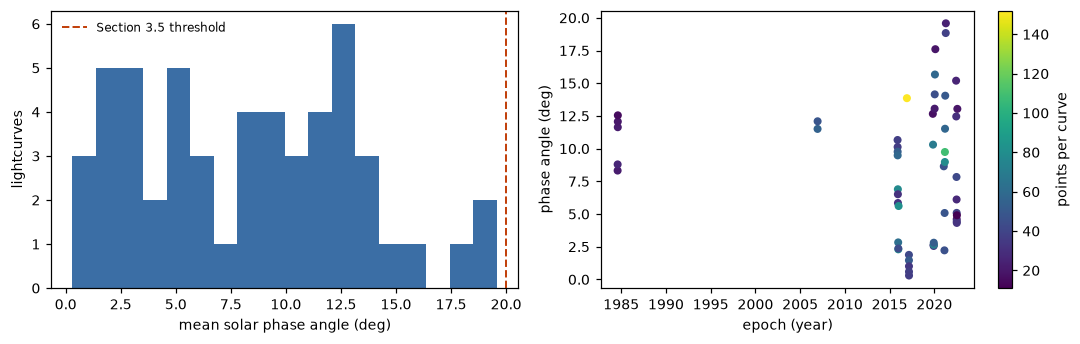

In [4]:
alpha = np.degrees([c.mean_phase_angle for c in data])
npts = np.array([len(c) for c in data])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(alpha, bins=18, color="#3b6ea5")
axes[0].axvline(20, color="#c2410c", ls="--", lw=1.3, label="Section 3.5 threshold")
axes[0].set_xlabel("mean solar phase angle (deg)"); axes[0].set_ylabel("lightcurves")
axes[0].legend(fontsize=8, frameon=False)

jd = np.array([c.jd.mean() for c in data])
axes[1].scatter((jd - 2451545.0) / 365.25 + 2000, alpha, s=18, c=npts, cmap="viridis")
axes[1].set_xlabel("epoch (year)"); axes[1].set_ylabel("phase angle (deg)")
fig.colorbar(axes[1].collections[0], ax=axes[1], label="points per curve")
fig.tight_layout()

print(f"max phase angle reached: {alpha.max():.1f} deg")
print(f"curves above 20 deg    : {(alpha > 20).sum()} of {len(alpha)}")

## 2. The direct problem (Section 2)

Before inverting anything, check the forward model. The paper's central empirical
claim about nonconvex bodies is:

> It is actually quite surprising how similar the lightcurves of even a strongly
> nonconvex body and its convex hull are.

`RayTracer` implements the local-blocker scheme of Section 2 — for each facet it
finds "which vertices are above [the] facet's local horizon and which facets
connected to these vertices are facing this facet", and tests only those.

peanut : Polyhedron(258 vertices, 512 facets),  nonconvexity 11.7%


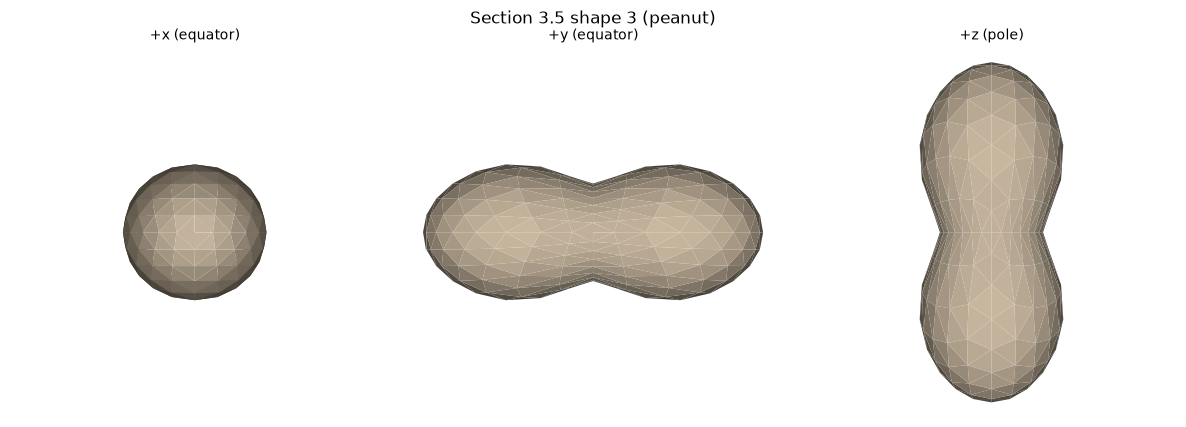

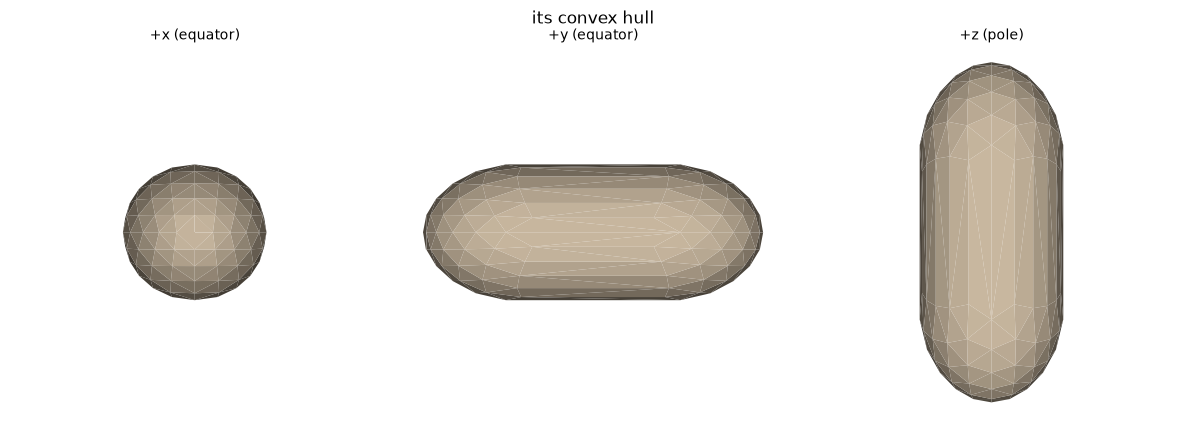

In [5]:
body = lcinv.paper_shape("peanut", n_rows=8)     # Section 3.5, shape 3
hull = body.convex_hull()
print(f"peanut : {body},  nonconvexity {1 - body.volume / hull.volume:.1%}")

fig = plotting.plot_shape_views(body, title="Section 3.5 shape 3 (peanut)")
fig = plotting.plot_shape_views(hull, title="its convex hull")

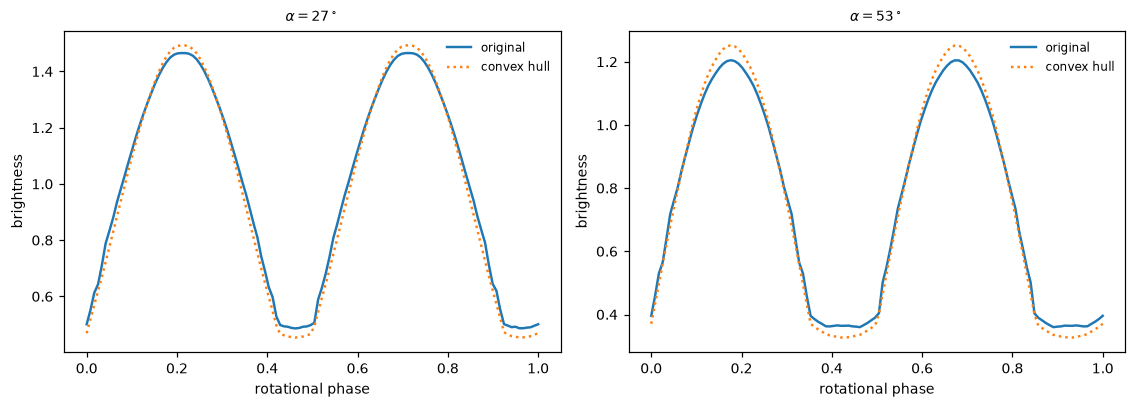

In [6]:
# Two geometries, as in panel (d) of Figures 1-4.
def geometry(alpha_deg, tilt=0.0):
    a = np.radians(alpha_deg)
    earth = np.array([np.cos(0.0), np.sin(0.0), tilt])
    sun = np.array([np.cos(a), np.sin(a), -tilt])
    return earth / np.linalg.norm(earth), sun / np.linalg.norm(sun)

fig = plotting.plot_lightcurve_comparison(
    {"original": body, "convex hull": hull},
    [geometry(27.0), geometry(53.0)],
)
for ax, a in zip(fig.axes, (27, 53)):
    ax.set_title(f"$\\alpha = {a}^\\circ$", fontsize=9)

The two curves are nearly indistinguishable once the hull is rescaled by Eq. (14) —
which is precisely why convex inversion works at all, and equally why it cannot
recover the concavity itself.

## 3. Convex inversion (Section 3.2)

Justitia's photometry is **relative**, so the objective is Eq. (13):

$$\chi^2_{\rm rel} = \sum_i \left\| \frac{L^{(i)}}{\bar{L}^{(i)}} - \frac{A^{(i)} g}{\langle A^{(i)} g\rangle} \right\|^2$$

which "renormalises both the observed and the model lightcurves to mean brightnesses
of unity", discarding every per-curve scale factor.

We use the paper's own Lommel-Seeliger + Lambert law rather than DAMIT's published
Hapke parameters. DAMIT fits Justitia with a Hapke model including macroscopic
roughness $\bar\theta = 20^\circ$; `lcinv.Hapke` implements the Hapke law
**without** the roughness correction, so using it here would silently misapply the
published parameters. The LSL law is what both Kaasalainen papers use.

In [7]:
geo = lcinv.FacetGeometry.from_sphere(8)      # 8 x 8^2 = 512 facet normals
law = lcinv.LommelSeeligerLambert(0.1, lcinv.PhaseFunction(0.5, 0.1, -0.5))
print(f"{len(geo)} surface normals, {(6 + 1) ** 2} harmonic coefficients")

series = lcinv.HarmonicInversion(
    data, geo, model.spin, lmax=6, law=law,
    objective=lcinv.Objective.RELATIVE, convexity_weight=0.1,
    fit_pole=True, fit_period=False,
)
result = series.run(max_iter=60)
print(f"chi2 = {result.chi2:.4f}   rms = {result.rms:.5f}   ({result.n_iterations} evaluations)")
print(f"pole  lambda = {result.spin.lam:.2f} deg, beta = {result.spin.beta:.2f} deg")
print(f"DAMIT lambda = {model.spin.lam:.2f} deg, beta = {model.spin.beta:.2f} deg")
print(f"pole difference: {lcinv.compare_poles(result.spin, model.spin):.2f} deg")
print(f"residual nonconvexity |sum n_j g_j| / sum g_j = {result.nonconvexity:.4f}")

512 surface normals, 49 harmonic coefficients


chi2 = 0.4813   rms = 0.01435   (84 evaluations)
pole  lambda = 76.59 deg, beta = -74.28 deg
DAMIT lambda = 73.00 deg, beta = -81.00 deg
pole difference: 6.76 deg
residual nonconvexity |sum n_j g_j| / sum g_j = 0.0056


Section 3.3 gives the yardstick for that last number:

> The ratio of the size of the residual nonconvexity (3) to the total surface area
> varied between 0.001 and 0.007 for the four shapes.

A value in that range means the lightcurve variation is being explained by shape
alone, with no albedo variegation required.

## 4. Facet refinement (Section 3.1)

Section 3.5 recommends the two-stage approach: the series method gives "a fast
initial solution that can then be enhanced with the polyhedron method", where each
facet gets its own parameter $g_j = \exp(a_j)$ and $\chi^2$ is minimised by
conjugate gradients.

In [8]:
facet = lcinv.FacetInversion(
    data, geo, result.spin, law=law,
    objective=lcinv.Objective.RELATIVE, convexity_weight=0.1,
).run(initial=result.areas, max_iter=600)

print(f"series : chi2 = {result.chi2:.4f}  rms = {result.rms:.5f}")
print(f"facets : chi2 = {facet.chi2:.4f}  rms = {facet.rms:.5f}")
print(f"improvement: {100 * (1 - facet.chi2 / result.chi2):.1f}%")
print(f"residual nonconvexity: {facet.nonconvexity:.4f}")

series : chi2 = 0.4813  rms = 0.01435
facets : chi2 = 0.4553  rms = 0.01396
improvement: 5.4%
residual nonconvexity: 0.0052


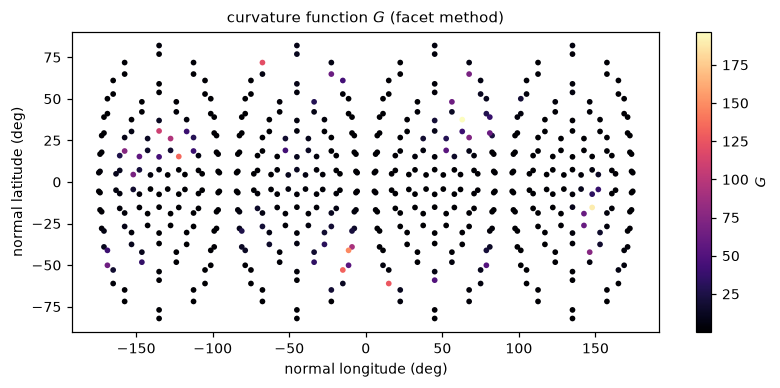

In [9]:
fig = plotting.plot_facet_values(geo, facet.areas, title="curvature function $G$ (facet method)")

## 5. The fit to the data

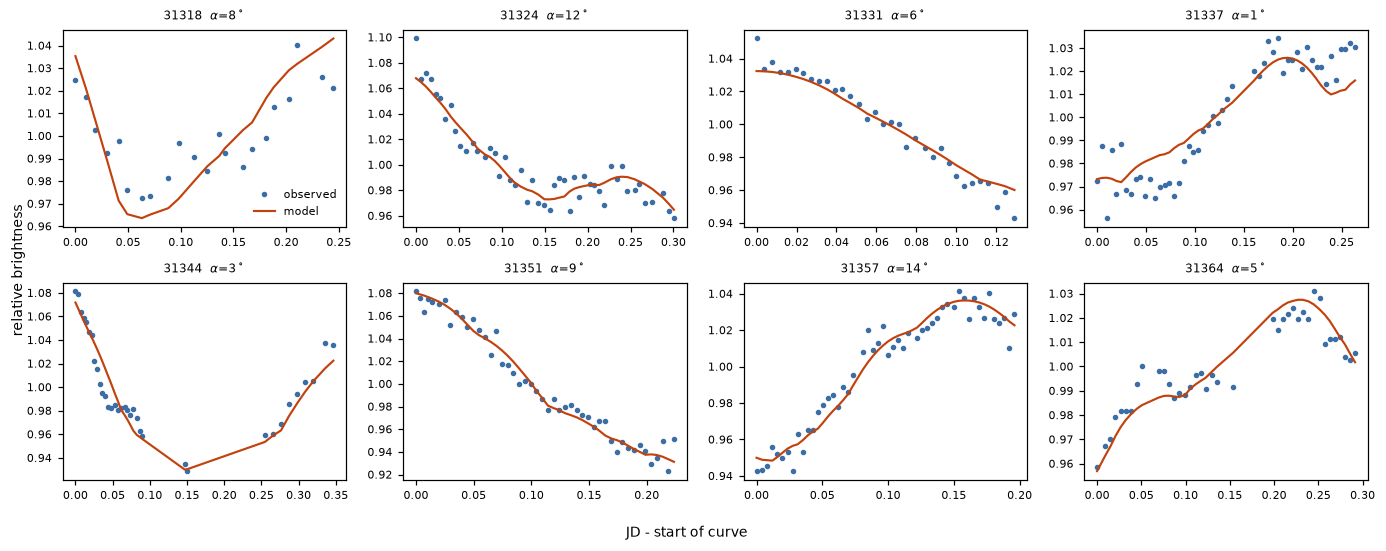

In [10]:
fig = plotting.plot_lightcurve_grid(data, facet.model_lightcurves, max_curves=8, n_cols=4)

## 6. Shape from the facet areas (Appendix C)

Inversion recovers only the *areas* of the facets. Turning them back into a body is
the Minkowski problem: maximise the volume $V = \frac{1}{3}\sum_j l_j A_j(l)$ over
the plane distances $l$ while holding $\langle l, g \rangle$ fixed, with the
projected gradient $f = A - \frac{\langle A, g\rangle}{\langle g, g\rangle} g$
of Eq. (18), and the dual transform $r = n / l$ of Eq. (19) to build the polyhedron.

In [11]:
shape = lcinv.minkowski_solve(geo.normals, facet.areas, max_iter=250)
print(f"{shape.n_iterations} iterations, alignment <A,g>/(|A||g|) = {shape.alignment:.8f}")
print(f"converged: {shape.converged};  closing dark facet: {shape.dark_area / facet.areas.sum():.2%} of the area")

recovered = shape.polyhedron.to_unit_volume()
published = model.shape.to_unit_volume()
a, b, c = recovered.extents()
pa, pb, pc = published.extents()
print(f"\nrecovered  a:b:c = {a / c:.3f} : {b / c:.3f} : 1.000")
print(f"DAMIT      a:b:c = {pa / pc:.3f} : {pb / pc:.3f} : 1.000")

250 iterations, alignment <A,g>/(|A||g|) = 0.99999956
converged: False;  closing dark facet: 0.51% of the area

recovered  a:b:c = 1.234 : 1.120 : 1.000
DAMIT      a:b:c = 1.412 : 1.228 : 1.000


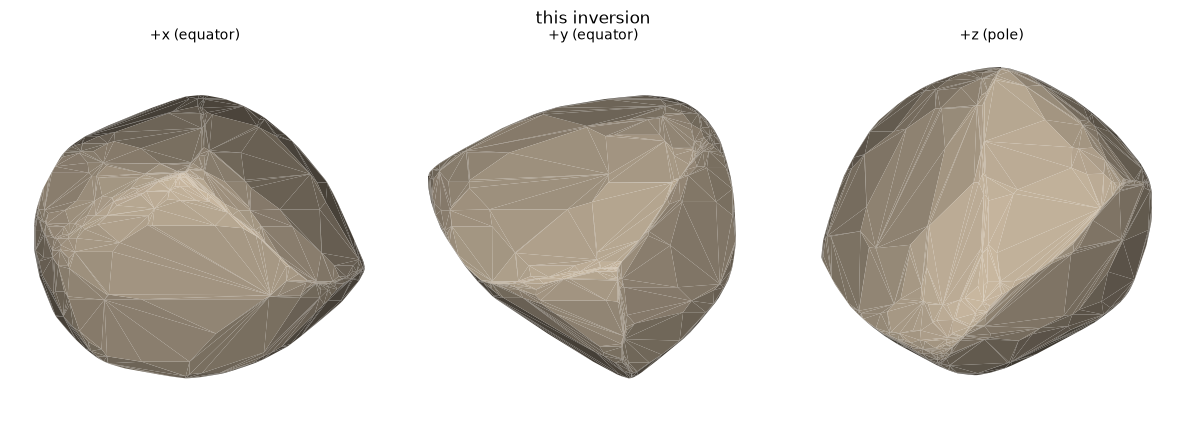

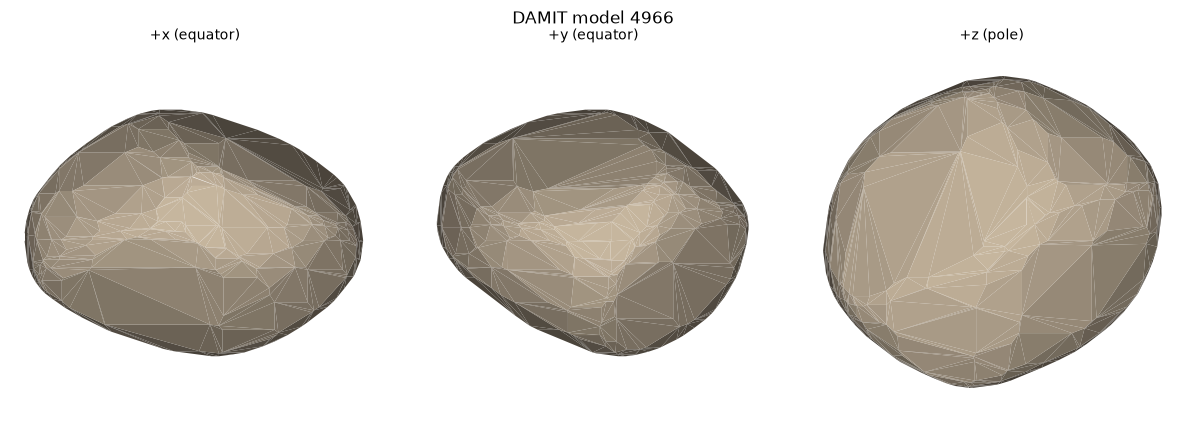

In [12]:
fig = plotting.plot_shape_views(recovered, title="this inversion")
fig = plotting.plot_shape_views(published, title="DAMIT model 4966")

## 7. Nonconvex inversion (Section 4)

Section 4 drops the convexity assumption and optimises the *vertex radii* of a
triangulated surface directly, through Eq. (15):

$$r(\theta, \varphi) = \exp\left(\sum_{lm} c_{lm} Y_{lm}(\theta, \varphi)\right)$$

Trial lightcurves now come from the ray tracer, so shadowing is modelled rather
than assumed away. The paper is blunt about the cost:

> This problem is a very demanding one, the main complications being that all
> uniqueness theorems are lost and the parameter space is usually plagued by local
> minima.

and about how to run it: truncate the series early ("at order and degree four"), and
start from a good guess — "the series fitted to a convex inversion result".

In [13]:
# Ray tracing every point is expensive, so use a geometry-spread subset.
subset = data.select_geometries(10)
print(f"using {subset}")

series_nc = lcinv.RadialShapeSeries(n_rows=5, lmax=3)   # 200 facets, 16 coefficients
print(f"{series_nc.n_parameters} shape coefficients, {8 * 5 ** 2} facets")

nc = lcinv.NonconvexInversion(
    subset, result.spin, series=series_nc, law=law,
    objective=lcinv.Objective.RELATIVE,
    regularisation=0.0,
)

# Section 4's recommended start: fit the series to the convex solution.
start = series_nc.fit(recovered)
nc_result = nc.run(initial=start, max_nfev=250)

print(f"start   chi2 = {float(np.sum(nc._residuals(start) ** 2)):.4f}")
print(f"fitted  chi2 = {nc_result.chi2:.4f}   rms = {nc_result.rms:.5f}")
print(f"convexity penalty (area sunk below the hull) = {nc_result.convexity_penalty:.4f}")
body_nc = nc_result.body
print(f"nonconvexity of the solution: {1 - body_nc.volume / body_nc.convex_hull().volume:.1%}")

using LightcurveSet(10 curves, 483 points)
16 shape coefficients, 200 facets


start   chi2 = 0.5214
fitted  chi2 = 0.3220   rms = 0.02590
convexity penalty (area sunk below the hull) = 1.0081
nonconvexity of the solution: 23.3%


In [14]:
# The same subset, fitted convexly, is the fair comparison.
convex_subset = lcinv.FacetInversion(
    subset, geo, result.spin, law=law,
    objective=lcinv.Objective.RELATIVE, convexity_weight=0.1,
).run(initial=facet.areas, max_iter=400)

print(f"convex    chi2 = {convex_subset.chi2:.4f}  rms = {convex_subset.rms:.5f}")
print(f"nonconvex chi2 = {nc_result.chi2:.4f}  rms = {nc_result.rms:.5f}")

convex    chi2 = 0.2426  rms = 0.02248
nonconvex chi2 = 0.3220  rms = 0.02590


Paper II sets the bar a nonconvex model has to clear:

> In principle the reliability conditions are quite obvious: at least as good a
> $\chi^2$ as that of the convex model, and the same major surface features from
> different initial values and regularization strengths. In practice, these
> conditions typically seem to be fulfilled no better than moderately well.

Compare the two numbers above before reading anything into the shape below. With
Justitia's phase-angle coverage capped near 20°, there is very little shadowing
signal in the data for the nonconvex model to work with, so a genuine improvement
would be surprising.

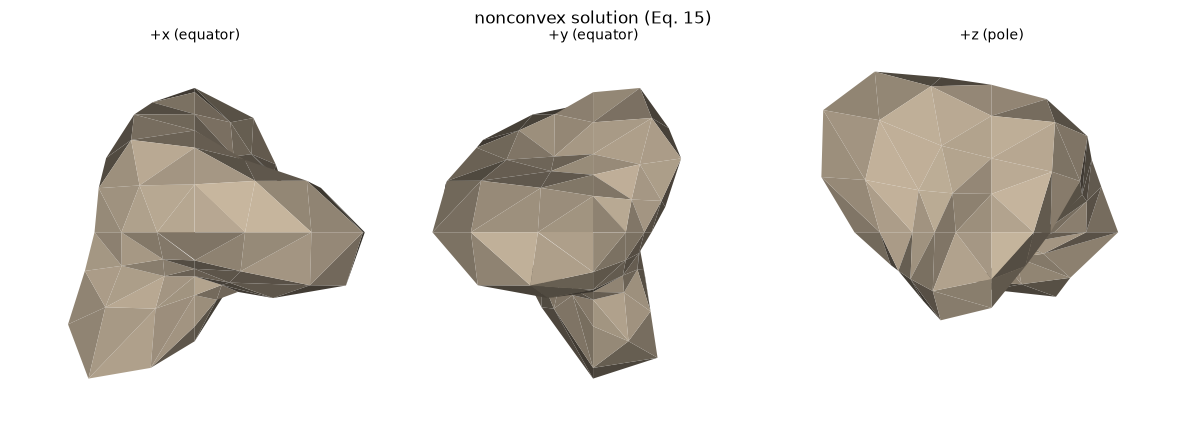

In [15]:
fig = plotting.plot_shape_views(body_nc.to_unit_volume(), title="nonconvex solution (Eq. 15)")

Section 4 also supplies a regulariser for this problem — "minimize the area 'sunk
below' the convex hull of the current result" — which `convexity_penalty` computes
from the ray tracer's own local-blocker bookkeeping. Turning it up drives the
solution back towards convexity.

In [16]:
for weight in (0.0, 1.0, 20.0):
    r_ = lcinv.NonconvexInversion(
        subset, result.spin, series=series_nc, law=law, regularisation=weight,
    ).run(initial=start, max_nfev=120)
    depth = 1 - r_.body.volume / r_.body.convex_hull().volume
    print(f"regularisation {weight:5.1f}:  chi2 = {r_.chi2:.4f}   "
          f"sunk area = {r_.convexity_penalty:.4f}   nonconvexity = {depth:.1%}")

regularisation   0.0:  chi2 = 0.3220   sunk area = 1.0081   nonconvexity = 23.3%


regularisation   1.0:  chi2 = 0.4383   sunk area = 0.0242   nonconvexity = 0.6%


regularisation  20.0:  chi2 = 0.5091   sunk area = 0.0006   nonconvexity = 0.0%


## 8. How well is the pole actually determined?

The paper estimates uncertainty by repetition — Section 5 suggests repeating the
inversion "with different (but nearby) initial values ... to obtain error
estimates". `BayesianInversion` keeps the same forward model and the same
exponential positivity of Eq. (6), but samples the posterior with `emcee`, adding an
isotropic $p(\beta) \propto \cos\beta$ pole prior and a free noise level.

This is a short chain for demonstration; a publication run needs far more steps.

In [17]:
# Seed the chain at the optimiser's solution, with the same free parameters,
# so burn-in only has to explore the mode rather than find it.
geo_mc = lcinv.FacetGeometry.from_sphere(5)
seed_fit = lcinv.HarmonicInversion(
    data, geo_mc, model.spin, lmax=2, law=law,
    convexity_weight=0.0, convexity_components="none", fit_pole=True,
).run(max_iter=60)

bayes = lcinv.BayesianInversion(data, geo_mc, model.spin, lmax=2, law=law, fit_pole=True)
print(f"{bayes.n_dim} sampled parameters, ending {bayes.labels[-3:]}")

posterior = bayes.run(
    n_walkers=44, n_steps=900, burn=450, seed=0,
    start=bayes.start_from_result(seed_fit), pole_scatter=1.0,
)
print(f"acceptance fraction {posterior.acceptance_fraction:.2f}")
for name in ("lambda", "beta", "log_sigma"):
    s = posterior.summary()[name]
    print(f"  {name:>9} = {s['median']:8.3f}  +{s['upper']:.3f} / -{s['lower']:.3f}")
print(f"\nimplied noise level: {np.exp(posterior.summary()['log_sigma']['median']):.3f} (fractional)")

12 sampled parameters, ending ['lambda', 'beta', 'log_sigma']


The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 18;
tau: [120.0918621   92.2217853   98.69654538 100.09045187 123.9831129
 128.19003457 125.83478237 121.85119731  57.4802929   43.96249478
  73.63947294  60.72172957]


acceptance fraction 0.18
     lambda =   49.209  +8.516 / -8.111
       beta =  -85.478  +1.852 / -2.193
  log_sigma =   -3.462  +0.094 / -0.052

implied noise level: 0.031 (fractional)


Justitia's pole is close to the ecliptic south pole ($\beta \approx -80^\circ$), and
there the *longitude is nearly meaningless* — near the pole all $\lambda$ describe
almost the same direction. So quoting $\lambda \pm \sigma$ is misleading; the
angular distance between spin axes is the quantity that has physical content.

angular distance from the DAMIT pole: 5.4 deg  (16-84%: 4.2 - 7.2)
posterior spread about its own mean  : 2.10 deg


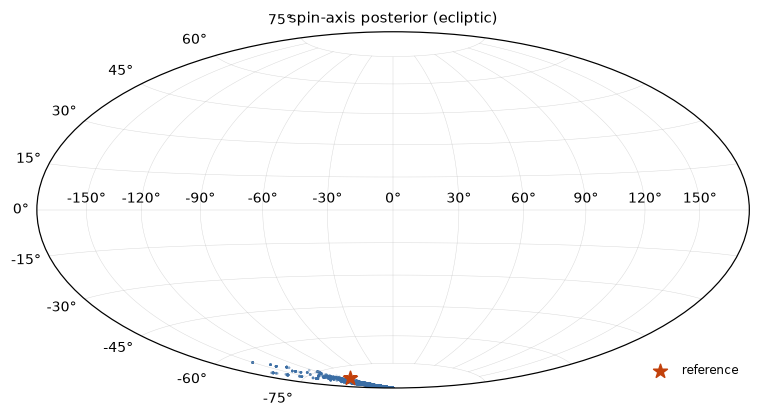

In [18]:
lam = posterior.samples[:, posterior.labels.index("lambda")]
beta = posterior.samples[:, posterior.labels.index("beta")]

# Angular distance of every posterior sample from the DAMIT pole.
truth = model.spin.pole_vector()
b, l = np.radians(beta), np.radians(lam)
vectors = np.column_stack([np.cos(b) * np.cos(l), np.cos(b) * np.sin(l), np.sin(b)])
separation = np.degrees(np.arccos(np.clip(vectors @ truth, -1, 1)))

lo, mid, hi = np.percentile(separation, [16, 50, 84])
print(f"angular distance from the DAMIT pole: {mid:.1f} deg  (16-84%: {lo:.1f} - {hi:.1f})")
print(f"posterior spread about its own mean  : {np.degrees(np.arccos(np.clip(vectors @ (vectors.mean(0) / np.linalg.norm(vectors.mean(0))), -1, 1))).std():.2f} deg")

fig = plotting.plot_pole_samples(lam, beta, truth=(model.spin.lam, model.spin.beta))

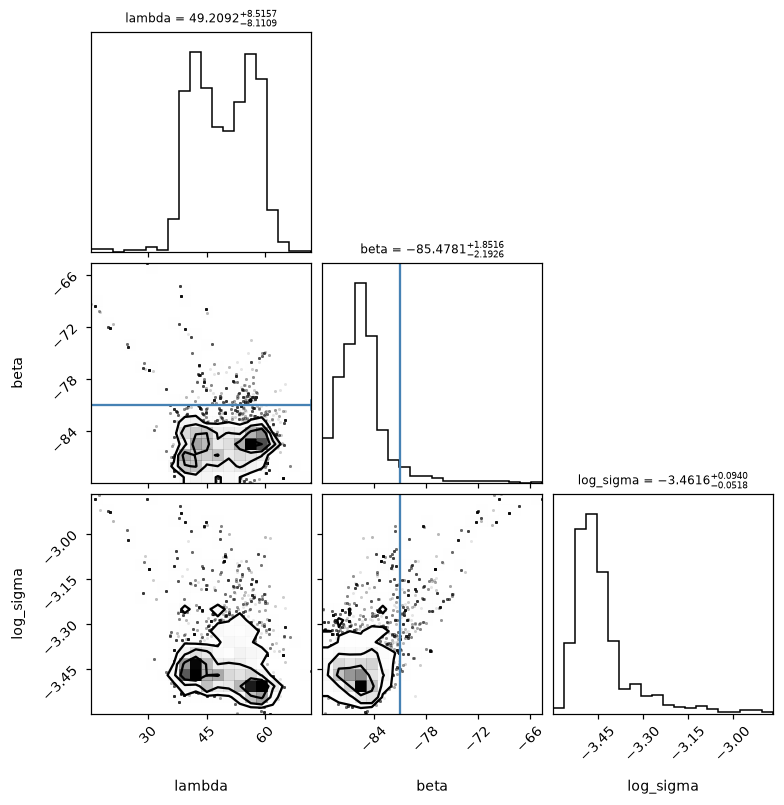

In [19]:
fig = plotting.plot_corner(
    posterior,
    parameters=["lambda", "beta", "log_sigma"],
    truths=[model.spin.lam, model.spin.beta, None],
)

## 9. What to take away

* The inversion reproduces DAMIT's pole to within a few degrees and fits the 53
  lightcurves at the few-percent level, using only the methods of Paper I.
* The residual nonconvexity sits in the range Section 3.3 associates with a
  constant-albedo body, so no albedo variegation is called for.
* **The phase-angle coverage is the binding constraint.** Justitia never exceeds
  ~20°, and Section 3.5 is explicit that "due to the lack of shadowing effects,
  shape information in observations made at small solar phases is often restricted
  to the general dimensions of the target". The overall dimensions here are
  trustworthy; fine surface detail is not.
* The nonconvex fit does not clearly beat the convex one, which is the expected
  outcome for a target that never reaches large solar phase angles — Section 4's
  method needs shadowing to have something to bite on.
* The shape is a *convex* solution. As Section 3.5 puts it, the convex hull "is a
  convex shape that actually describes a (reasonably ordinary) nonconvex body well
  since the locations of the concavities are seen in the convex hull as large planar
  sections" — large flat facets mark where concavities probably are, but their
  depths are unrecoverable from photometry alone.

### Reproducing this

```bash
pip install -e ".[dev,plot,bayes]"
lcinv fetch 4966          # download
lcinv invert 4966 --restarts 3 --out outputs/justitia.obj
```

### Citing

* Kaasalainen & Torppa (2001), Icarus **153**, 24 — the methods.
* Kaasalainen, Torppa & Muinonen (2001), Icarus **153**, 37 — the complete recipe.
* Ďurech, Sidorin & Kaasalainen (2010), A&A **513**, A46 — DAMIT.
* The per-lightcurve references preserved in `curve.meta["references"]`.

In [20]:
refs = {}
for curve in data:
    for r in curve.meta.get("references", []):
        refs[r["bibcode"]] = f"{r['author_short']} ({r['year']})"
for bibcode, who in sorted(refs.items(), key=lambda kv: kv[1]):
    print(f"  {who:<28} {bibcode}")

  Marciniak et al. (2025)      2025psj.....6...60m
